## Aim: 

Appraise areas of BCFZ using NDVI (Normalised Difference Vegetation Index) and derivatives (i.e. Laplace, variance).

In [1]:
import matplotlib.pyplot as plt
import rasterio as rio
import numpy as np
from pathlib import Path
import glob

In [2]:
paths = glob.glob('../../../data/NDVI/*/composite.tif')

In [3]:
import numpy as np

def calculate_evi(nir, red, blue):
    """Calculates standard 3-band Enhanced Vegetation Index (EVI)."""
    # Define standard MODIS coefficients
    G = 2.5
    C1 = 6.0
    C2 = 7.5
    L = 1.0
    
    # Calculate denominator
    denominator = nir + (C1 * red) - (C2 * blue) + L
    
    # Avoid division by zero using numpy.where
    evi = np.where(
        denominator != 0, 
        G * (nir - red) / denominator, 
        np.nan
    )
    return evi

def calculate_evi2(nir, red):
    """Calculates 2-band Enhanced Vegetation Index (EVI2)."""
    # Calculate denominator
    denominator = nir + (2.4 * red) + 1.0
    
    # Avoid division by zero
    evi2 = np.where(
        denominator != 0, 
        2.5 * (nir - red) / denominator, 
        np.nan
    )
    return evi2

In [4]:
tiles = []

for p in paths:
    with rio.open(p) as src:
        b = src.read(1).astype(np.float32) / 10000.0
        r = src.read(3).astype(np.float32) / 10000.0
        nir = src.read(4).astype(np.float32) / 10000.0

        tiles.append([r, b, nir])

tiles = np.stack(tiles)
tiles = tiles[:, :, 4000:6000, 4000:7000]

In [5]:
evi_tiles = []
for i in range(len(tiles)):
    r = tiles[i, 0, :, :]
    nir = tiles[i, 2, :, :]
    b = tiles[i, 1, :, :]
    evi_tiles.append(calculate_evi(nir, r, b))

evi_tiles = np.stack(evi_tiles)

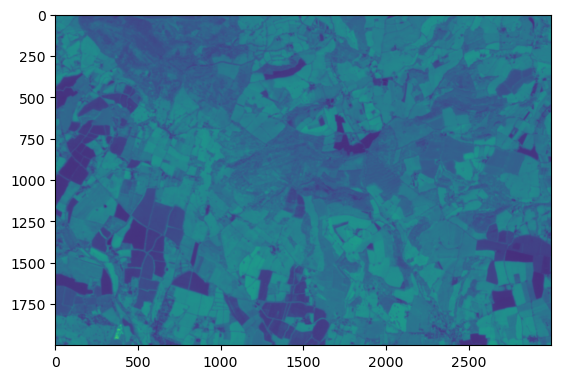

In [6]:
plt.imshow(evi_tiles[0])

In [7]:
evi_tiles.max()

np.float32(1.9971486)

In [8]:
var = np.var(evi_tiles, axis=0)

In [9]:
var.max(), var.mean()

(np.float32(0.39879867), np.float32(0.02536987))

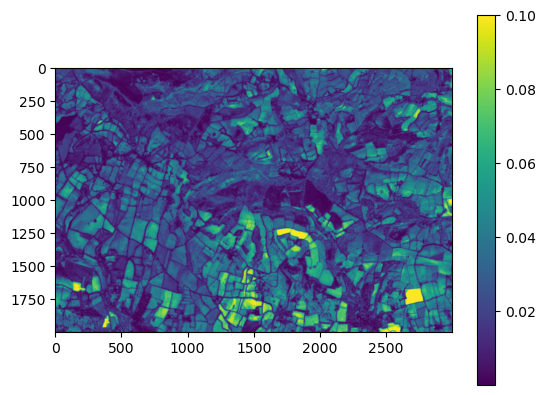

In [10]:
plt.imshow(var, vmax=0.1)
plt.colorbar()